**Import Libraries**


In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import TimeSeriesSplit

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler

# Pipeline
from sklearn.pipeline import Pipeline

# Column Transformer
from sklearn.compose import ColumnTransformer

# Preprocessing
from sklearn.impute import SimpleImputer

# Feature Selection
from sklearn.feature_selection import (
    SelectKBest,
    f_regression
)

# Regression Models
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

# Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Time Series Forecasting
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Export
import pickle

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')


Import dataset and check the data






In [2]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

print(df.head())
print('\n',df.shape)
print('\n',df.info())
print('\n',df.describe())
print('\n',df['Source_Type'].value_counts())
print('\n',df['Region'].value_counts())
print('\n',df['Model'].value_counts())

   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   CO2_Saved_tons           Source_Type  Charging_Stations  
0         1863.42  Interpolated (Month)              12207  
1          249.46    Official (Quarter)               7640  
2          

Data Cleaning and Preprocessing

Duplicates: 0

 Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


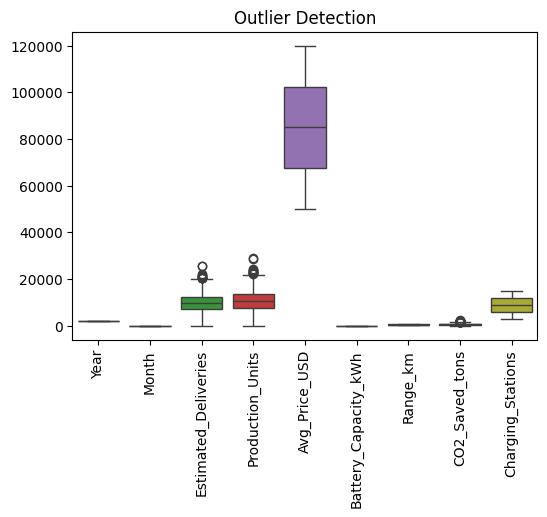

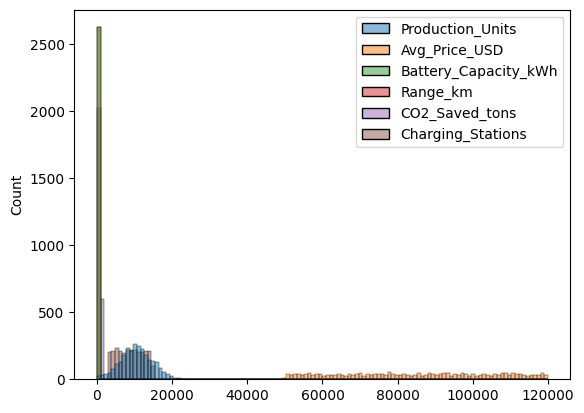

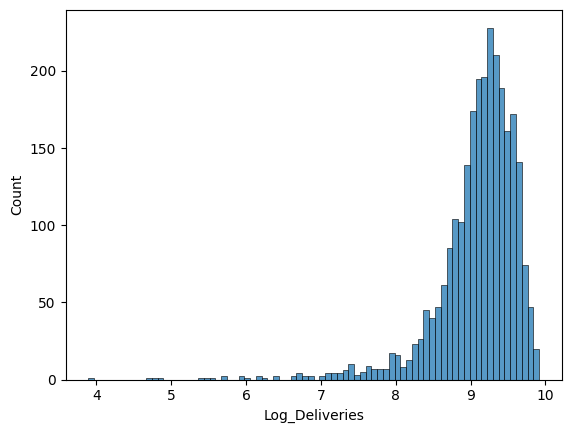

In [3]:
#Handling duplicates and null values
print("Duplicates:", df.duplicated().sum())
print('\n',df.isnull().sum())

#Outlier detection
plt.figure(figsize=(6,4))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Outlier Detection")
plt.show()

#Handle Outliers
Q1 = df['Estimated_Deliveries'].quantile(0.25)
Q3 = df['Estimated_Deliveries'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df = df[
    (df['Estimated_Deliveries'] >= lower) &
    (df['Estimated_Deliveries'] <= upper)
]


#FEATURE SCALING
num_cols = [
    'Production_Units',
    'Avg_Price_USD',
    'Battery_Capacity_kWh',
    'Range_km',
    'CO2_Saved_tons',
    'Charging_Stations'
]
cat_cols=['Source_Type', 'Region', 'Model']

#Initializing pipelines for column preprocessing

num_pipeline = Pipeline([
    ('imputer',
     SimpleImputer(strategy='median')),
    ('scaler',
     StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer',
     SimpleImputer(strategy='most_frequent')),
    ('encoder',
     OneHotEncoder(handle_unknown='ignore'))
])

#Column Preprocessing
preprocessor = ColumnTransformer([
    ('num',
     num_pipeline,
     num_cols),
    ('cat',
     cat_pipeline,
     cat_cols)
])

sns.histplot(df[num_cols])
plt.show()


# LOG TRANSFORMATION
df['Log_Deliveries'] = np.log1p(df['Estimated_Deliveries'])
sns.histplot(df['Log_Deliveries'])
plt.show()



Exploratory Data Analysis(EDA)

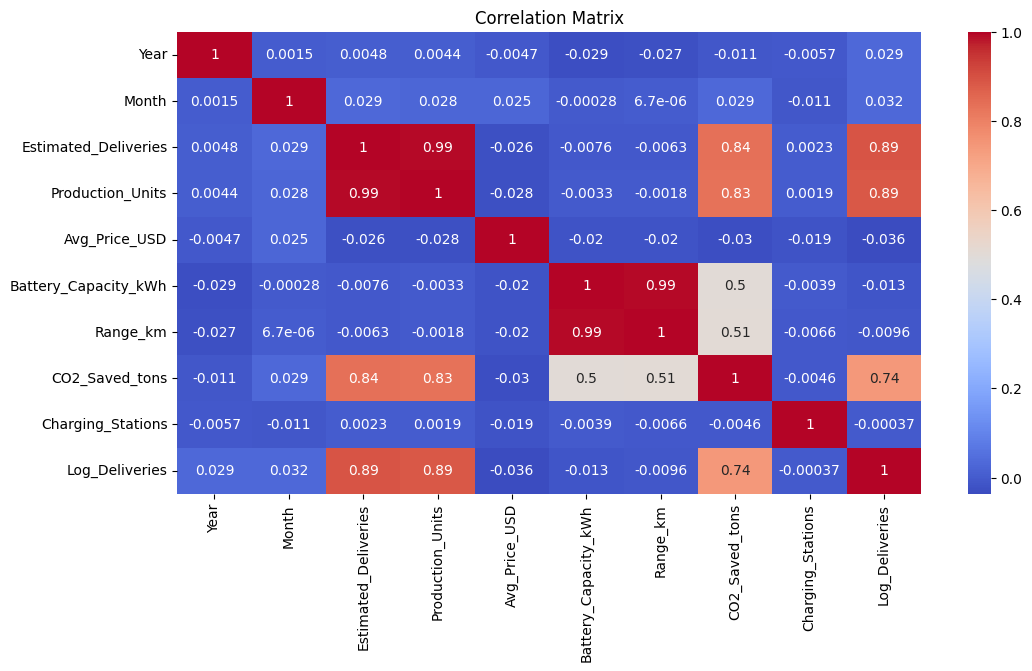

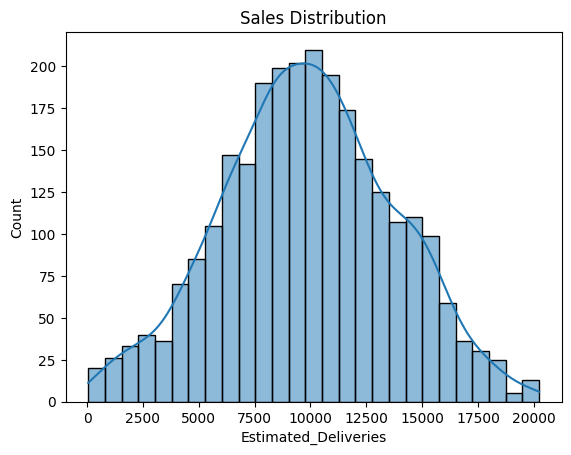

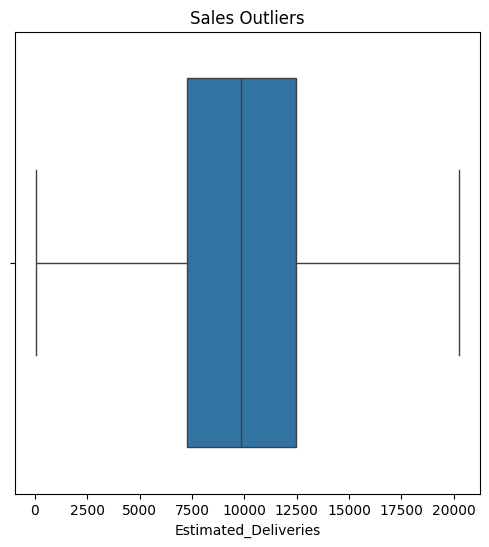

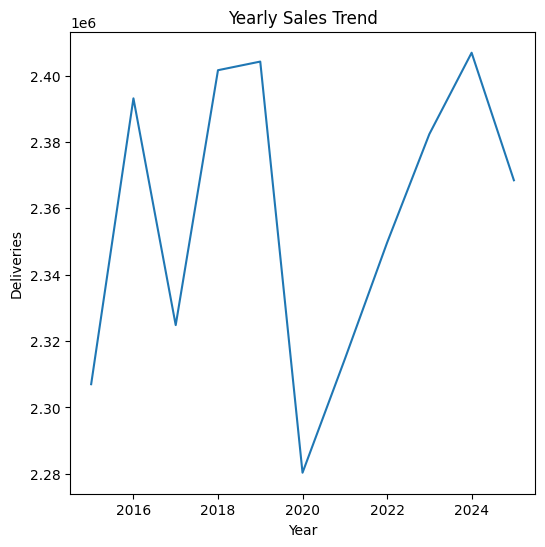

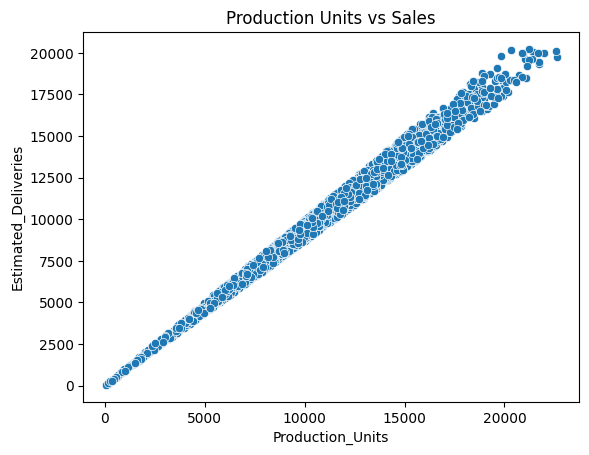

In [4]:


plt.figure(figsize=(12,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


sns.histplot(df['Estimated_Deliveries'], kde=True)
plt.title("Sales Distribution")
plt.show()


plt.figure(figsize=(6,6))
sns.boxplot(x=df['Estimated_Deliveries'])
plt.title("Sales Outliers")
plt.show()


monthly_sales = df.groupby('Year')['Estimated_Deliveries'].sum()
monthly_sales.plot(figsize=(6,6))
plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Deliveries")
plt.show()


sns.scatterplot(
    x='Production_Units',
    y='Estimated_Deliveries',
    data=df
)
plt.title("Production Units vs Sales")
plt.show()

Feature Engineering and Selection

      Year  Month       Region       Model  Estimated_Deliveries  \
2159  2015     12         Asia  Cybertruck                  4993   
1457  2015      5       Europe     Model 3                 12077   
2516  2015      5  Middle East     Model S                 11967   
1462  2015      3         Asia  Cybertruck                 10257   
1468  2015      6         Asia     Model Y                  6828   

      Avg_Price_USD  Battery_Capacity_kWh  Range_km  CO2_Saved_tons  \
2159       83124.69                   100       598          447.87   
1457       76240.94                    75       423          766.29   
2516       79277.01                   100       596         1069.85   
1462       65107.47                   100       581          893.90   
1468       75498.89                   100       575          588.91   

               Source_Type  Charging_Stations  Log_Deliveries       Date  \
2159    Official (Quarter)               5226        8.515992 2015-01-01   
1457  Interp

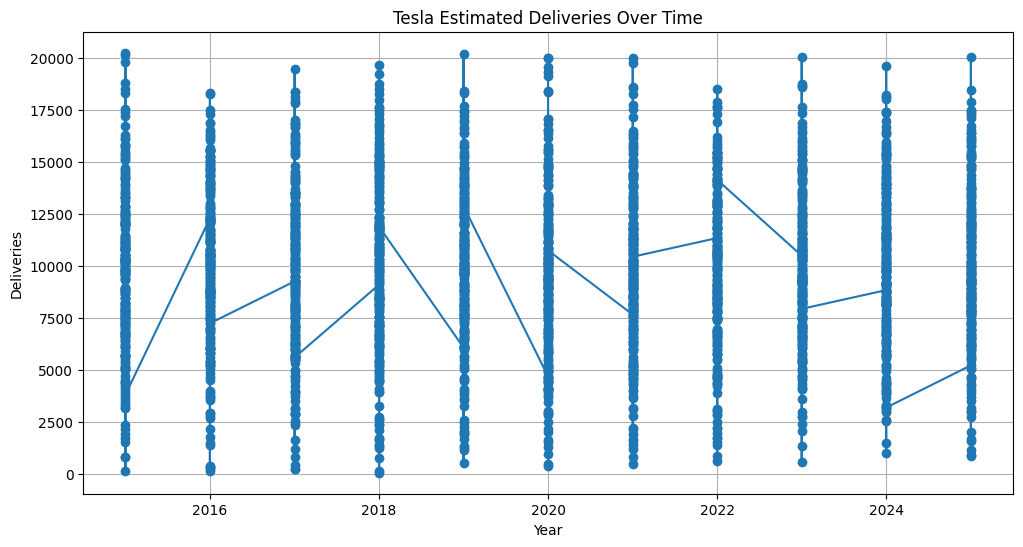

In [5]:
#Remove data leakage
df.drop(
    columns=['Production_Units'],
    inplace=True
)

# CREATE DATE COLUMN
df['Date'] = pd.to_datetime(
    df['Year'].astype(str) + '-01-01'
)

# SORT BY TIME
df = df.sort_values('Date')

#Previous year deivery as input
df['Prev_Year_Delivery'] = (
    df['Estimated_Deliveries']
    .shift(1)
)

#Rolling mean
df['Rolling_Mean_3'] = (
    df['Estimated_Deliveries']
    .rolling(3)
    .mean()
)
df.dropna(inplace=True)
print(df.head())

#visualize time-series
plt.figure(figsize=(12,6))
plt.plot(
    df['Date'],
    df['Estimated_Deliveries'],
    marker='o'
)
plt.title('Tesla Estimated Deliveries Over Time')
plt.xlabel('Year')
plt.ylabel('Deliveries')
plt.grid(True)
plt.show()



Model Training, Evaluation and Selection


MSE: 517278.6479321922
RMSE: 719.2208617192581
R2: 0.9625075911639256


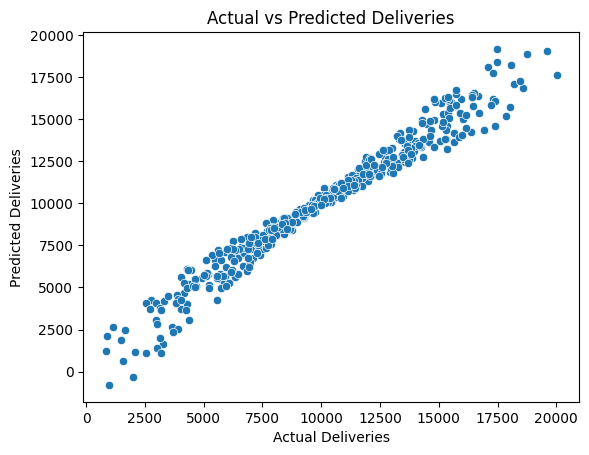

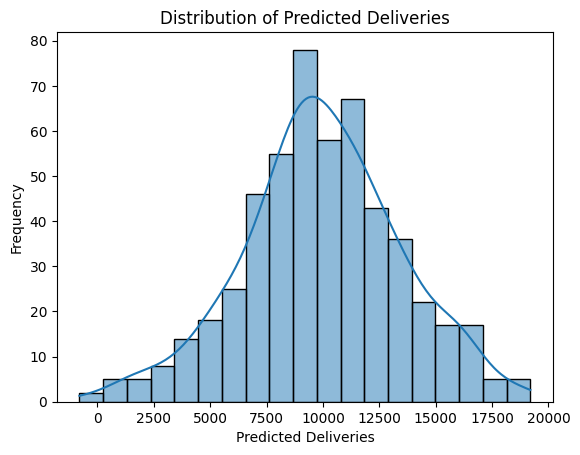

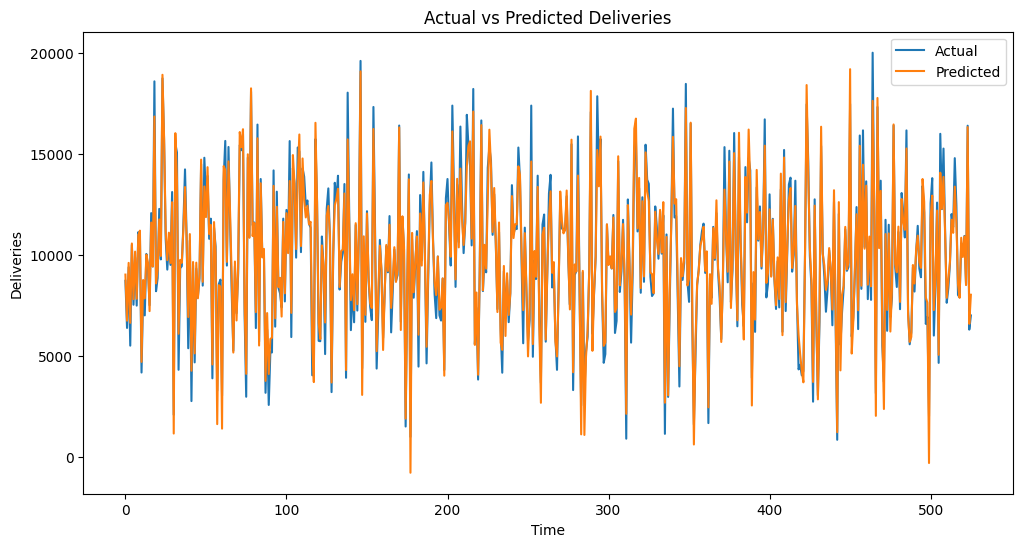

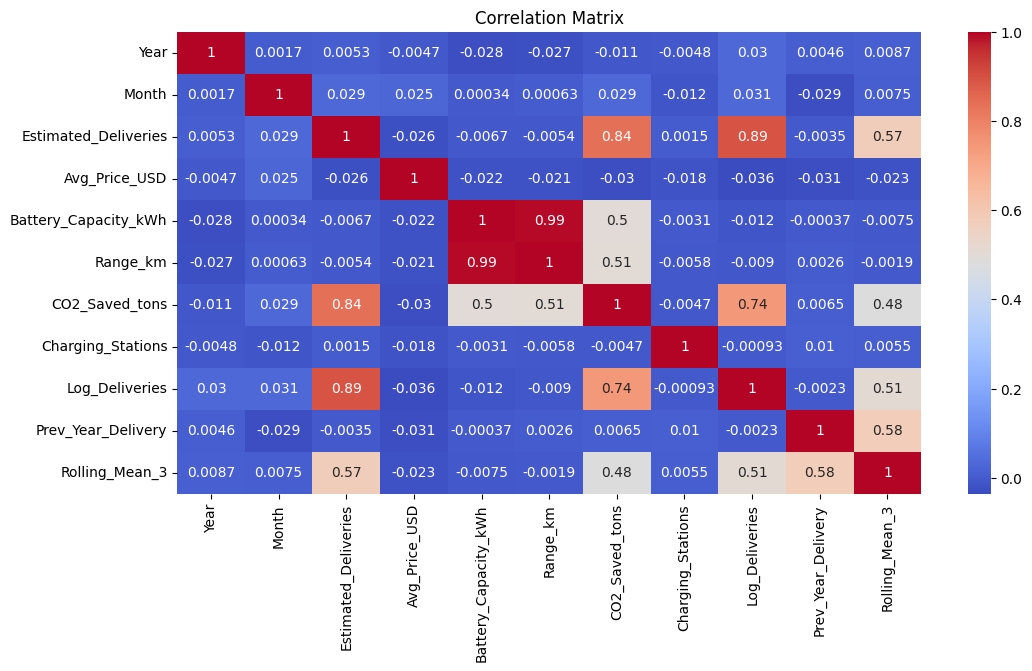

CROSS VALIDATION
[0.95287156 0.95774964 0.94785393 0.95237121 0.95630104]

Mean CV Score
0.9534294772601827


In [6]:
target = 'Estimated_Deliveries'

X = df.drop(
    columns=[
        target,
        'Date'
    ]
)
y = df[target]

#Chronological split
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test  = X.iloc[split:]

y_train = y.iloc[:split]
y_test  = y.iloc[split:]

# Define updated numerical and categorical columns for preprocessing.
num_cols_updated = [
    'Avg_Price_USD',
    'Battery_Capacity_kWh',
    'Range_km',
    'CO2_Saved_tons',
    'Charging_Stations',
    'Prev_Year_Delivery',
    'Rolling_Mean_3',
    'Log_Deliveries'
]
cat_cols = ['Source_Type', 'Region', 'Model']

# Re-define Column Preprocessor with the updated column lists
preprocessor = ColumnTransformer([
    ('num',
     num_pipeline,
     num_cols_updated),
    ('cat',
     cat_pipeline,
     cat_cols)
])

# Re-define ML- Pipeline with the updated preprocessor
pipe = Pipeline([

    ('preprocessor',
     preprocessor),

    ('feature_selection',
     SelectKBest(
         score_func=f_regression,
         k='all'
     )),
    ('model',
     Ridge())
])

# Train Model
pipe.fit(
    X_train,
    y_train
)

y_pred = pipe.predict(X_test)

# Model Evaluation
mae = mean_squared_error(
    y_test,
    y_pred
)
print("MSE:", mae)

rmse=np.sqrt(mae)
print("RMSE:", rmse)

r2= r2_score(y_test, y_pred)
print("R2:", r2)

sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Deliveries")
plt.ylabel("Predicted Deliveries")
plt.title("Actual vs Predicted Deliveries")
plt.show()

sns.histplot(y_pred, kde=True)
plt.xlabel("Predicted Deliveries")
plt.ylabel("Frequency")
plt.title("Distribution of Predicted Deliveries")
plt.show()

plt.figure(figsize=(12,6))
plt.plot(
    y_test.values,
    label='Actual'
)
plt.plot(
    y_pred,
    label='Predicted'
)
plt.title('Actual vs Predicted Deliveries')
plt.xlabel('Time')
plt.ylabel('Deliveries')
plt.legend()
plt.show()

plt.figure(figsize=(12,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()



#  CROSS VALIDATION
tscv = TimeSeriesSplit(
    n_splits=5
)

cv_scores = cross_val_score(
    pipe,
    X_train,
    y_train,
    cv=tscv,
    scoring='r2'
)

print("CROSS VALIDATION")
print(cv_scores)
print("\nMean CV Score")
print(cv_scores.mean())


Hyperparameter Tuning

In [7]:
params = [
    {
        'model': [Ridge()],
        'model__alpha': [
            0.01,
            0.1,
            1,
            10,
            100
        ]
    },
    {
        'model': [Lasso()],
        'model__alpha': [
            0.01,
            0.1,
            1,
            10,
            100
        ]
    },
    {
        'model': [LinearRegression()]
    }
]

grid = GridSearchCV(
    pipe,
    param_grid=params,
    cv=tscv,
    scoring='r2',
    n_jobs=-1
)

grid.fit(
    X_train,
    y_train
)

print("BEST PARAMETERS")

print(grid.best_params_)

print("\nBest CV Score")
print(grid.best_score_)

#Evaluation
mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)

print("\nMAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)



BEST PARAMETERS
{'model': Lasso(), 'model__alpha': 10}

Best CV Score
0.9538132414885767

MAE : 532.74238364574
RMSE: 719.2208617192581
R2  : 0.9625075911639256


Time Series Forecasting


Average Forecast Values
[9866.7136329 9866.7136329 9866.7136329 9866.7136329 9866.7136329]

Naive Forecast Values
[6995 6995 6995 6995 6995]

Forecast DataFrame
   Average_Forecast  Naive_Forecast  ARIMA_Forecast
0       9866.713633            6995     9867.158179
1       9866.713633            6995     9863.193161
2       9866.713633            6995     9863.198635
3       9866.713633            6995     9863.198627
4       9866.713633            6995     9863.198627


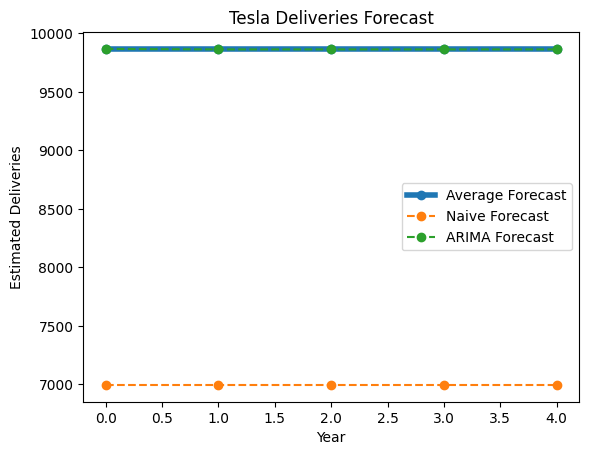

In [8]:
# Average of historical deliveries
avg_value = df['Estimated_Deliveries'].mean()
# Forecast next 5 years using average

avg_forecast = np.repeat(
    avg_value,
    5
)
print("\nAverage Forecast Values")
print(avg_forecast)


# Last observed value
last_value = df['Estimated_Deliveries'].iloc[-1]
# Forecast next 5 years using last value

naive_forecast = np.repeat(
    last_value,
    5
)
print("\nNaive Forecast Values")
print(naive_forecast)

# ARIMA MODEL
from statsmodels.tsa.arima.model import ARIMA

# Train ARIMA Model
arima_model = ARIMA(
    df['Estimated_Deliveries'],
    order=(1,1,1)
)

arima_fit = arima_model.fit()
# Forecast next 5 years
arima_forecast = arima_fit.forecast(steps=5)


#Visualization
forecast_df = pd.DataFrame({

    'Average_Forecast': avg_forecast,
    'Naive_Forecast': naive_forecast,
    'ARIMA_Forecast': arima_forecast.values

})
print("\nForecast DataFrame")
print(forecast_df)


# Average Forecast
plt.plot(
    forecast_df['Average_Forecast'],
    marker='o',
    linestyle='solid',
    linewidth=4,
    label='Average Forecast'
)

# Naive Forecast
plt.plot(
    forecast_df['Naive_Forecast'],
    marker='o',
    linestyle='--',
    label='Naive Forecast'
)

# Arima
plt.plot(
    forecast_df['ARIMA_Forecast'],
    linestyle='--',
    marker='o',
    label='ARIMA Forecast'
)


plt.title(
    'Tesla Deliveries Forecast'
)

plt.xlabel('Year')
plt.ylabel('Estimated Deliveries')
plt.legend()
plt.show()

In [9]:
best_model = grid.best_estimator_

#SAVE PIPELINE
pickle.dump(
    best_model,
    open(
        'tesla_pipeline.pkl',
        'wb'
    ))

print("\nPipeline Saved Successfully!")

#LOAD PIPELINE
loaded_model = pickle.load(
    open(
        'tesla_pipeline.pkl',
        'rb'
    ))

print("\nPipeline Loaded Successfully!")

# SAMPLE PREDICTIONS
sample_data = X_test.iloc[:5]
sample_preds = loaded_model.predict(
    sample_data
)
print("\nSample Predictions")
print(sample_preds)


Pipeline Saved Successfully!

Pipeline Loaded Successfully!

Sample Predictions
[ 9039.33669842  6717.3401679   9555.61417529  6664.26295202
 10623.57954857]
